In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
#Load data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)


X_train shape: (69600, 128, 128, 3)
y_train shape: (69600, 29)
X_val shape: (17400, 128, 128, 3)
y_val shape: (17400, 29)


In [28]:
#check data range
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: -1.0
Max pixel value: 1.0


In [29]:
#check label format
print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Unique labels: [0. 1.]
Number of classes: 2


In [30]:
print("y_train sample:", y_train[0])

y_train sample: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


In [31]:
y_train = np.argmax(y_train, axis=1)
y_val = np.argmax(y_val, axis=1)

In [32]:
print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
Number of classes: 29


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

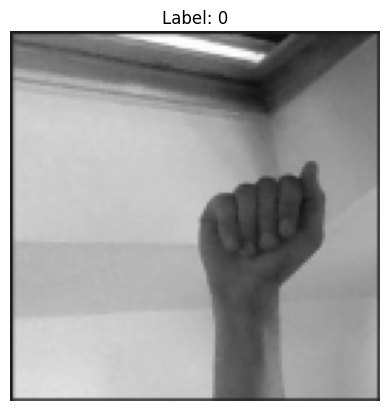

In [33]:
plt.imshow((X_train[0] + 1) / 2)  # convert back to [0,1] for display
plt.title(f"Label: {y_train[0]}")
plt.axis("off")

In [34]:
import torch

X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
X_val = torch.tensor(X_val).permute(0, 3, 1, 2).float()

y_train = torch.tensor(y_train).long()
y_val = torch.tensor(y_val).long()

print("X_train shape:", X_train.shape)

X_train shape: torch.Size([69600, 3, 128, 128])


In [35]:
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


### Load MobileNetV2

In [36]:
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)

### Modify Final Layer

In [37]:
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 29)

### Freeze Feature Extractor

In [38]:
for param in model.features.parameters():
    param.requires_grad = False

### Move Model to Device

In [39]:
model = model.to(device)

### Verify Model

In [40]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=29, bias=True)
)


### Check Trainable Parameters

In [41]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable)
print("Total params:", total)

Trainable params: 37149
Total params: 2261021


### Create DataLoader

In [42]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Loss Function

In [43]:
criterion = nn.CrossEntropyLoss()

### Optimizer

In [44]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training Loop

In [45]:
import time

num_epochs = 10

# Early stopping settings
patience = 3
counter = 0
best_val_loss = float('inf')
best_val_acc = 0

# History tracking
train_losses_1 = []
val_losses_1 = []
train_accs_1 = []
val_accs_1 = []

for epoch in range(num_epochs):
    start_time = time.time()

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    avg_train_loss = train_loss / len(train_loader)
    
    train_losses_1.append(avg_train_loss)
    train_accs_1.append(train_acc)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)

    val_losses_1.append(avg_val_loss)
    val_accs_1.append(val_acc)

    # ================= LOGGING =================
    duration = time.time() - start_time

    print(f"\nEpoch {epoch+1} Summary:")
    print(f" Train: Loss={avg_train_loss:.4f}, Acc={train_acc*100:.2f}%")
    print(f" Val:   Loss={avg_val_loss:.4f}, Acc={val_acc*100:.2f}%")
    print(f" Time:  {duration:.1f}s")

    # ================= SAVE BEST MODEL (ACCURACY) =================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f" >> New best validation accuracy: {val_acc*100:.2f}%")

    # ================= EARLY STOPPING (LOSS) =================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        print(" >> Validation loss improved, saving model")

        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1
        print(f" >> No improvement ({counter}/{patience})")

        if counter >= patience:
            print("\n Early stopping triggered!")
            break

    print("-" * 60)


Epoch 1 Summary:
 Train: Loss=0.7219, Acc=79.90%
 Val:   Loss=0.2865, Acc=92.22%
 Time:  460.6s
 >> New best validation accuracy: 92.22%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 2 Summary:
 Train: Loss=0.3995, Acc=87.38%
 Val:   Loss=0.2052, Acc=93.76%
 Time:  428.6s
 >> New best validation accuracy: 93.76%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 3 Summary:
 Train: Loss=0.3584, Acc=88.19%
 Val:   Loss=0.1788, Acc=94.28%
 Time:  434.1s
 >> New best validation accuracy: 94.28%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 4 Summary:
 Train: Loss=0.3479, Acc=88.53%
 Val:   Loss=0.1602, Acc=95.05%
 Time:  434.2s
 >> New best validation accuracy: 95.05%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 5 Summary:
 Train: Loss=0

### Unfreeze last layers

In [46]:
# Unfreeze last few layers of feature extractor
for param in model.features[-4:].parameters():
    param.requires_grad = True

In [47]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Trainable params after unfreezing:", trainable)
print("Total params:", total)

Trainable params after unfreezing: 1563229
Total params: 2261021


### Using smaller learning rate

In [48]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [49]:
criterion = torch.nn.CrossEntropyLoss()

### Training with fewer epochs(smaller learning rate)

In [50]:
num_epochs = 5  

patience = 3
counter = 0
best_val_loss = float('inf')
best_val_acc = 0

# History tracking
train_losses_2 = []
val_losses_2 = []
train_accs_2 = []
val_accs_2 = []

for epoch in range(num_epochs):
    start_time = time.time()

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    avg_train_loss = train_loss / len(train_loader)
    
    train_losses_2.append(avg_train_loss)
    train_accs_2.append(train_acc)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)

    val_losses_2.append(avg_val_loss)
    val_accs_2.append(val_acc)

    # ================= LOGGING =================
    duration = time.time() - start_time

    print(f"\n[Fine-Tune] Epoch {epoch+1} Summary:")
    print(f" Train: Loss={avg_train_loss:.4f}, Acc={train_acc*100:.2f}%")
    print(f" Val:   Loss={avg_val_loss:.4f}, Acc={val_acc*100:.2f}%")
    print(f" Time:  {duration:.1f}s")

    # Track best accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f" >> New best validation accuracy: {val_acc*100:.2f}%")

    # Early stopping (based on loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        print(" >> Validation loss improved, saving model")

        torch.save(model.state_dict(), "best_model_finetuned.pth")

    else:
        counter += 1
        print(f" >> No improvement ({counter}/{patience})")

        if counter >= patience:
            print("\n Early stopping triggered!")
            break

    print("-" * 60)


[Fine-Tune] Epoch 1 Summary:
 Train: Loss=0.1287, Acc=95.78%
 Val:   Loss=0.0280, Acc=99.10%
 Time:  483.6s
 >> New best validation accuracy: 99.10%
 >> Validation loss improved, saving model
------------------------------------------------------------

[Fine-Tune] Epoch 2 Summary:
 Train: Loss=0.0431, Acc=98.60%
 Val:   Loss=0.0171, Acc=99.41%
 Time:  459.0s
 >> New best validation accuracy: 99.41%
 >> Validation loss improved, saving model
------------------------------------------------------------

[Fine-Tune] Epoch 3 Summary:
 Train: Loss=0.0354, Acc=98.88%
 Val:   Loss=0.0085, Acc=99.70%
 Time:  455.7s
 >> New best validation accuracy: 99.70%
 >> Validation loss improved, saving model
------------------------------------------------------------

[Fine-Tune] Epoch 4 Summary:
 Train: Loss=0.0258, Acc=99.18%
 Val:   Loss=0.0176, Acc=99.49%
 Time:  451.8s
 >> No improvement (1/3)
------------------------------------------------------------

[Fine-Tune] Epoch 5 Summary:
 Train: Loss=

### Visualize graphs

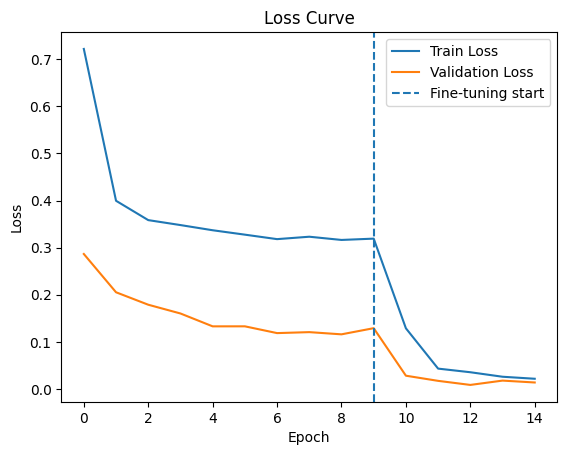

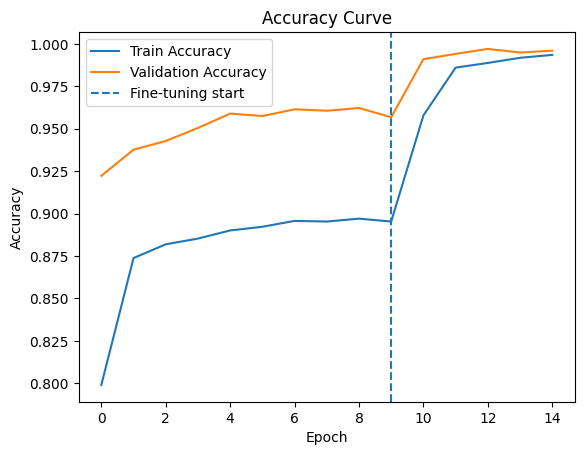

In [51]:
train_losses = train_losses_1 + train_losses_2
val_losses = val_losses_1 + val_losses_2
train_accs = train_accs_1 + train_accs_2
val_accs = val_accs_1 + val_accs_2

# Loss
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=len(train_losses_1)-1, linestyle='--', label='Fine-tuning start')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy
plt.figure()
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.axvline(x=len(train_accs_1)-1, linestyle='--', label='Fine-tuning start')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()